# 🔤 OCR with CRNN and CTC Loss: Synthetic License Plates

This notebook builds an OCR pipeline for synthetic license plate recognition using a **Convolutional Recurrent Neural Network (CRNN)**.

## Table of Contents
1. OCR Overview
2. CRNN Architecture
3. Synthetic Dataset Generation
4. Text Encoding
5. CTC Loss
6. Model Training
7. Prediction Decoding
8. Error Analysis
9. Industry Uses
10. Key Learnings, Interview Questions, Common Mistakes, Further Reading


## 1. OCR Overview

OCR converts text in images into machine-readable characters. License plates are a practical OCR example because they contain short sequences with constrained alphabets.

```mermaid
flowchart LR
    A[Plate image] --> B[CNN visual features]
    B --> C[Sequence reshape]
    C --> D[BiLSTM context modeling]
    D --> E[CTC decoding]
    E --> F[Predicted text]
```

A CRNN uses CNN layers for visual feature extraction and recurrent layers for reading the feature sequence from left to right.


In [1]:
# Reproducibility and common imports
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [2]:
try:
    import tensorflow as tf
    from PIL import Image, ImageDraw, ImageFont
except ImportError:
    %pip install -q tensorflow pillow
    import tensorflow as tf
    from PIL import Image, ImageDraw, ImageFont

tf.random.set_seed(SEED)


## 2. Generate a Synthetic License Plate Dataset

A synthetic dataset keeps the notebook self-contained and reproducible. In a production project, this would be replaced or augmented with real labeled plate images.


In [3]:
CHARS = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
MAX_LEN = 7
IMG_WIDTH = 160
IMG_HEIGHT = 50
NUM_SAMPLES = 2500

char_to_num = tf.keras.layers.StringLookup(vocabulary=list(CHARS), mask_token=None)
num_to_char = tf.keras.layers.StringLookup(vocabulary=char_to_num.get_vocabulary(), mask_token=None, invert=True)

def random_plate():
    letters = "".join(random.choices("ABCDEFGHIJKLMNOPQRSTUVWXYZ", k=3))
    digits = "".join(random.choices("0123456789", k=4))
    return letters + digits

def render_plate(text):
    img = Image.new("L", (IMG_WIDTH, IMG_HEIGHT), color=235)
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype("Arial.ttf", 28)
    except OSError:
        font = ImageFont.load_default()
    bbox = draw.textbbox((0, 0), text, font=font)
    x = (IMG_WIDTH - (bbox[2] - bbox[0])) // 2
    y = (IMG_HEIGHT - (bbox[3] - bbox[1])) // 2
    draw.rectangle([4, 4, IMG_WIDTH - 5, IMG_HEIGHT - 5], outline=60, width=2)
    draw.text((x, y), text, fill=20, font=font)
    arr = np.array(img).astype("float32") / 255.0
    noise = np.random.normal(0, 0.03, arr.shape)
    arr = np.clip(arr + noise, 0, 1)
    return arr[..., None]

labels = [random_plate() for _ in range(NUM_SAMPLES)]
images = np.stack([render_plate(label) for label in labels])
print(images.shape, labels[:5])


(2500, 50, 160, 1) ['CTG1175', 'PAC2657', 'SKL2871', 'KHF7133', 'IGB4190']


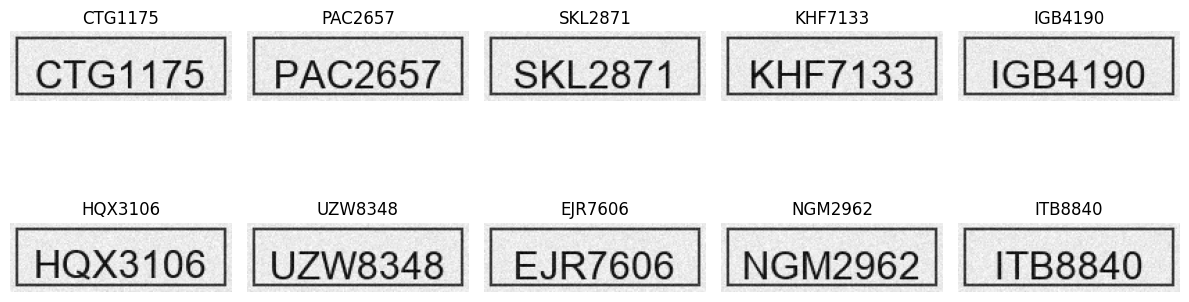

In [4]:
plt.figure(figsize=(12, 5))
for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(labels[i])
    plt.axis("off")
plt.tight_layout()


## 3. Encode Labels and Build TensorFlow Datasets


In [5]:
def encode_label(label):
    chars = tf.strings.unicode_split(label, input_encoding="UTF-8")
    return char_to_num(chars)

encoded_labels = tf.ragged.constant([list(label) for label in labels])
encoded_labels = char_to_num(encoded_labels).to_tensor(default_value=0, shape=[None, MAX_LEN])

split = int(NUM_SAMPLES * 0.8)
x_train, x_val = images[:split], images[split:]
y_train, y_val = encoded_labels[:split], encoded_labels[split:]
label_train, label_val = labels[:split], labels[split:]

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(1024, seed=SEED).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(32).prefetch(tf.data.AUTOTUNE)


## 4. CTC Loss

CTC loss trains sequence models when we know the final text label but do not know the exact alignment between image columns and characters.


In [6]:
class CTCLayer(tf.keras.layers.Layer):
    def __init__(self, name=None):
        super().__init__(name=name)
        self.loss_fn = tf.keras.backend.ctc_batch_cost

    def call(self, y_true, y_pred):
        batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
        input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
        label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")
        input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
        label_length = label_length * tf.ones(shape=(batch_len, 1), dtype="int64")
        loss = self.loss_fn(y_true, y_pred, input_length, label_length)
        self.add_loss(loss)
        return y_pred


## 5. Build CRNN Architecture

The CNN compresses image height and keeps a horizontal sequence. The recurrent layers then model character order.


In [7]:
def build_crnn():
    image = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1), name="image")
    labels_input = tf.keras.Input(shape=(MAX_LEN,), dtype="float32", name="label")

    x = tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same")(image)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    new_shape = ((IMG_WIDTH // 4), (IMG_HEIGHT // 4) * 64)
    x = tf.keras.layers.Reshape(target_shape=new_shape)(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True, dropout=0.25))(x)
    x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True, dropout=0.25))(x)
    x = tf.keras.layers.Dense(len(char_to_num.get_vocabulary()) + 1, activation="softmax", name="softmax")(x)
    output = CTCLayer(name="ctc_loss")(labels_input, x)
    return tf.keras.Model(inputs=[image, labels_input], outputs=output, name="license_plate_crnn")

model = build_crnn()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3))
model.summary()


Model: "license_plate_crnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 50, 160,   │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 50, 160,   │        320 │ image[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 25, 80,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 25, 80,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 12, 40,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 40, 768)   │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 40, 64)    │     49,216 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 40, 256)   │    197,632 │ dense[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 40, 128)   │    164,352 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label (InputLayer)  │ (None, 7)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Dense)     │ (None, 40, 38)    │      4,902 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ctc_loss (CTCLayer) │ (None, 40, 38)    │          0 │ label[0][0],      │
│                     │                   │            │ softmax[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 434,918 (1.66 MB)

 Trainable params: 434,918 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
train_for_ctc = train_ds.map(lambda x, y: ({"image": x, "label": y}, y))
val_for_ctc = val_ds.map(lambda x, y: ({"image": x, "label": y}, y))

history = model.fit(train_for_ctc, validation_data=val_for_ctc, epochs=12)


Epoch 1/12


/Users/mihrinur/.pyenv/versions/3.11.6/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 283ms/step - loss: 986.7148 - val_loss: 760.4320
Epoch 2/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 256ms/step - loss: 729.1906 - val_loss: 690.4782
Epoch 3/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 255ms/step - loss: 690.6309 - val_loss: 670.7485
Epoch 4/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 269ms/step - loss: 680.5932 - val_loss: 666.8690
Epoch 5/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 272ms/step - loss: 678.5483 - val_loss: 666.6594
Epoch 6/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 283ms/step - loss: 677.3663 - val_loss: 665.5021
Epoch 7/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 272ms/step - loss: 674.6306 - val_loss: 660.9094
Epoch 8/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 229ms/step - loss: 670.3588 - val_loss: 656.3761
Epoch 9/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 226ms/step - loss: 668.0906 - val_loss: 655.5809
Epoch 10/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 247ms/step - loss: 667.2100 - val_loss: 654.4761
Epoch 11/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 241ms/step - loss: 665.7340 - val_loss: 654.0030
Epoch 12

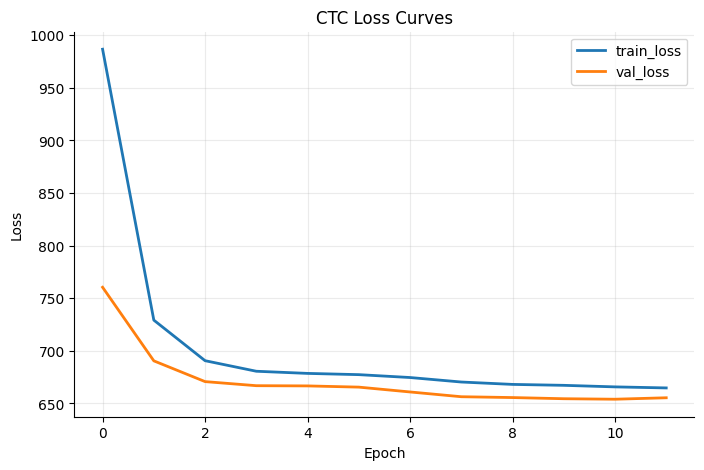

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train_loss", linewidth=2)
plt.plot(history.history["val_loss"], label="val_loss", linewidth=2)
plt.title("CTC Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


## Common OCR Errors

- Similar characters: `O` vs `0`, `I` vs `1`, `B` vs `8`.
- Motion blur or low contrast.
- Cropped text regions.
- Incorrect CTC decoding when the model has not learned enough alignment.

## Where CRNN Is Used in Industry

- License plate recognition
- Receipt and invoice OCR
- ID card text extraction
- Serial number recognition in manufacturing
- Document digitization pipelines

## Key Learnings

- CRNN combines spatial feature extraction and sequence modeling.
- CTC loss removes the need for frame-level character alignment.
- Synthetic data is useful for prototyping OCR systems.
- OCR needs both visual quality control and sequence-level evaluation.

## Interview Questions

1. Why is CTC useful for OCR?
2. What role does the CNN play in CRNN?
3. Why might synthetic OCR data fail on real-world images?
4. How would you evaluate OCR beyond exact-match accuracy?

## Common Mistakes

- Using a character set that does not match the labels.
- Forgetting the CTC blank token.
- Making the sequence width too short for the target text length.
- Evaluating only visual examples and not text accuracy.

## Further Reading

- CRNN paper: https://arxiv.org/abs/1507.05717
- Keras OCR example: https://keras.io/examples/vision/captcha_ocr/
- CTC loss overview: https://distill.pub/2017/ctc/
